# AI4I 2020 — EDA and Operator-Support Contribution (Robin)     

Companion notebooks:        
- `Mazen_modelling_contribution.ipynb`: supervised modelling contribution       
- `Joint_thesis_results_synthesis.ipynb`: synthesis of both individual contributions        

## 1. Imports, reproducibility, and environment

In [1]:
import platform, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import sklearn

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Python      :", platform.python_version())
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.11.14
numpy       : 2.4.4
pandas      : 3.0.2
matplotlib  : 3.10.8
scikit-learn: 1.8.0


## 2. Data loading and audit        

In [2]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
quality = pd.DataFrame({
    "dtype":          df.dtypes.astype(str),
    "missing_values": df.isna().sum(),
    "missing_%":      (df.isna().mean() * 100).round(2),
    "n_unique":       df.nunique(),
})
print(f"Duplicate rows: {df.duplicated().sum()}")
quality

Duplicate rows: 0


,dtype,missing_values,missing_%,n_unique
UDI,int64,0,0.0,10000
Product ID,str,0,0.0,10000
Type,str,0,0.0,3
Air temperature [K],float64,0,0.0,93
Process temperature [K],float64,0,0.0,82
Rotational speed [rpm],int64,0,0.0,941
Torque [Nm],float64,0,0.0,577
Tool wear [min],int64,0,0.0,246
Machine failure,int64,0,0.0,2
TWF,int64,0,0.0,2


### 2.1 Column roles        

In [4]:
TARGET = "Machine failure"
SUBTYPE_COLS = ["TWF", "HDF", "PWF", "OSF", "RNF"]
NUM_COLS = [
    "Air temperature [K]", "Process temperature [K]",
    "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
]

print(f"Numeric variables analysed: {len(NUM_COLS)}")

Numeric variables analysed: 5


## 3. Exploratory failure overview      

 class  count  percent
     0   9661    96.61
     1    339     3.39


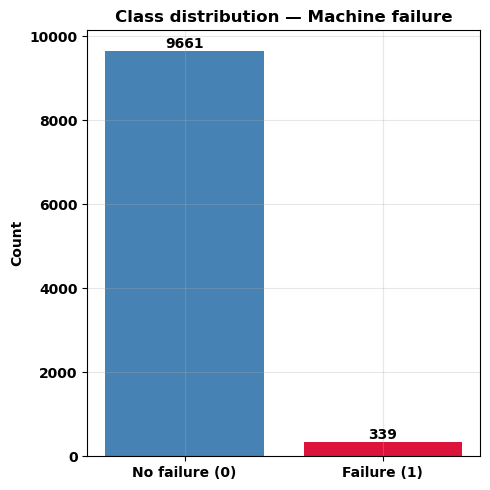

In [5]:
# Class distribution
tc = df[TARGET].value_counts().rename_axis("class").reset_index(name="count")
tc["percent"] = (tc["count"] / len(df) * 100).round(3)
print(tc.to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 5))
counts = tc.sort_values("class")["count"].values
bars = ax.bar(["No failure (0)", "Failure (1)"], counts, color=["steelblue", "crimson"])
ax.bar_label(bars, fmt="%d")
ax.set_title("Class distribution — Machine failure")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

      failures  total  failure_rate_%
Type                                 
H           21   1003            2.09
L          235   6000            3.92
M           83   2997            2.77


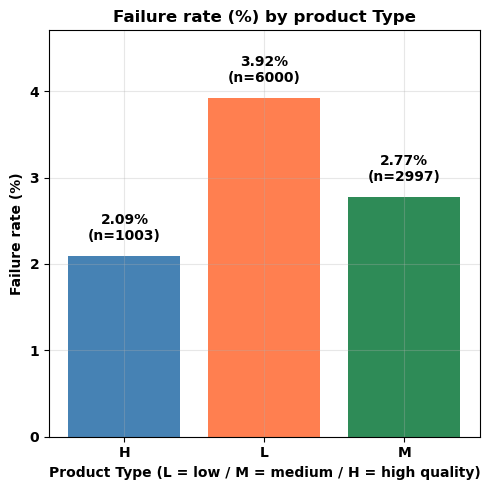

In [6]:
# Failure rate by Type
fbt = (df.groupby("Type")[TARGET]
       .agg(["sum", "count"])
       .rename(columns={"sum": "failures", "count": "total"}))
fbt["failure_rate_%"] = (fbt["failures"] / fbt["total"] * 100).round(2)
print(fbt)

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(fbt.index, fbt["failure_rate_%"], color=["steelblue", "coral", "seagreen"])
ax.set_title("Failure rate (%) by product Type")
ax.set_ylabel("Failure rate (%)")
ax.set_xlabel("Product Type (L = low / M = medium / H = high quality)")
ax.set_ylim(0, fbt["failure_rate_%"].max() * 1.2)
for i, (typ, row) in enumerate(fbt.iterrows()):
    ax.text(i, row["failure_rate_%"] + 0.15, f"{row['failure_rate_%']}%\n(n={int(row['total'])})",
            ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
# Subtype counts and OR-consistency check
sub_counts = df[SUBTYPE_COLS].sum().rename("count").to_frame()
sub_counts["share_of_failures_%"] = (sub_counts["count"] / df[TARGET].sum() * 100).round(2)
print("Subtype support counts:")
print(sub_counts)

subtype_or = df[SUBTYPE_COLS].any(axis=1).astype(int)
matches = (subtype_or == df[TARGET])
n_mismatch = int((~matches).sum())
print(f"\nMachine failure equals OR(subtypes) in {int(matches.sum())} / {len(df)} rows")
print(f"Mismatches: {n_mismatch}")

Subtype support counts:
     count  share_of_failures_%
TWF     46                13.57
HDF    115                33.92
PWF     95                28.02
OSF     98                28.91
RNF     19                 5.60

Machine failure equals OR(subtypes) in 9973 / 10000 rows
Mismatches: 27


## 4. Variable distributions by failure status      

In [8]:
# Summary table: mean, median, std for failures vs non-failures
def summary_by_failure(df, cols):
    rows = []
    for c in cols:
        for cls in [0, 1]:
            sub = df.loc[df[TARGET] == cls, c]
            rows.append({
                "variable": c,
                "class": "Failure" if cls == 1 else "No failure",
                "n": len(sub),
                "mean": sub.mean(),
                "median": sub.median(),
                "std": sub.std(),
                "min": sub.min(),
                "max": sub.max(),
            })
    return pd.DataFrame(rows)

var_summary = summary_by_failure(df, NUM_COLS)
print(var_summary.round(3).to_string(index=False))

               variable      class    n     mean  median     std    min    max
    Air temperature [K] No failure 9661  299.974   300.0   1.991  295.3  304.5
    Air temperature [K]    Failure  339  300.886   301.6   2.071  295.6  304.4
Process temperature [K] No failure 9661  309.996   310.0   1.487  305.7  313.8
Process temperature [K]    Failure  339  310.290   310.4   1.364  306.1  313.7
 Rotational speed [rpm] No failure 9661 1540.260  1507.0 167.395 1168.0 2695.0
 Rotational speed [rpm]    Failure  339 1496.487  1365.0 384.944 1181.0 2886.0
            Torque [Nm] No failure 9661   39.630    39.9   9.472   12.6   70.0
            Torque [Nm]    Failure  339   50.168    53.7  16.374    3.8   76.6
        Tool wear [min] No failure 9661  106.694   107.0  62.946    0.0  246.0
        Tool wear [min]    Failure  339  143.782   165.0  72.760    0.0  253.0


               variable  Cohen's d (failure − no failure)
            Torque [Nm]                             1.077
        Tool wear [min]                             0.586
    Air temperature [K]                             0.458
 Rotational speed [rpm]                            -0.244
Process temperature [K]                             0.199


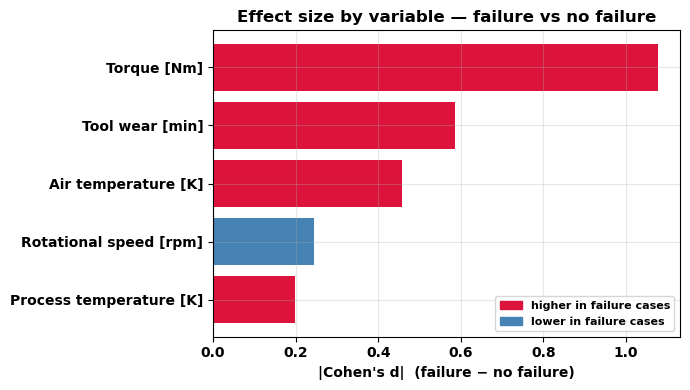

In [9]:
# Standardised mean difference (Cohen's d)
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = x.std(), y.std()
    pooled = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled if pooled > 0 else np.nan

eff = []
for c in NUM_COLS:
    xf = df.loc[df[TARGET] == 1, c]
    xn = df.loc[df[TARGET] == 0, c]
    eff.append({"variable": c, "Cohen's d (failure − no failure)": cohens_d(xf, xn)})
effect_df = pd.DataFrame(eff).sort_values("Cohen's d (failure − no failure)",
                                      key=abs, ascending=False).reset_index(drop=True)
print(effect_df.round(3).to_string(index=False))

# Cohen's d bar chart
d_col = "Cohen's d (failure − no failure)"
plot_df = effect_df.copy()
plot_df["abs_d"] = plot_df[d_col].abs()
plot_df = plot_df.sort_values("abs_d", ascending=True)  # ascending for barh

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["crimson" if v > 0 else "steelblue" for v in plot_df[d_col]]
ax.barh(plot_df["variable"], plot_df["abs_d"], color=colors)

# Add a legend for direction
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="crimson",   label="higher in failure cases"),
    Patch(color="steelblue", label="lower in failure cases"),
], fontsize=8)

ax.set_xlabel("|Cohen's d|  (failure − no failure)")
ax.set_title("Effect size by variable — failure vs no failure")
plt.tight_layout()
plt.show()

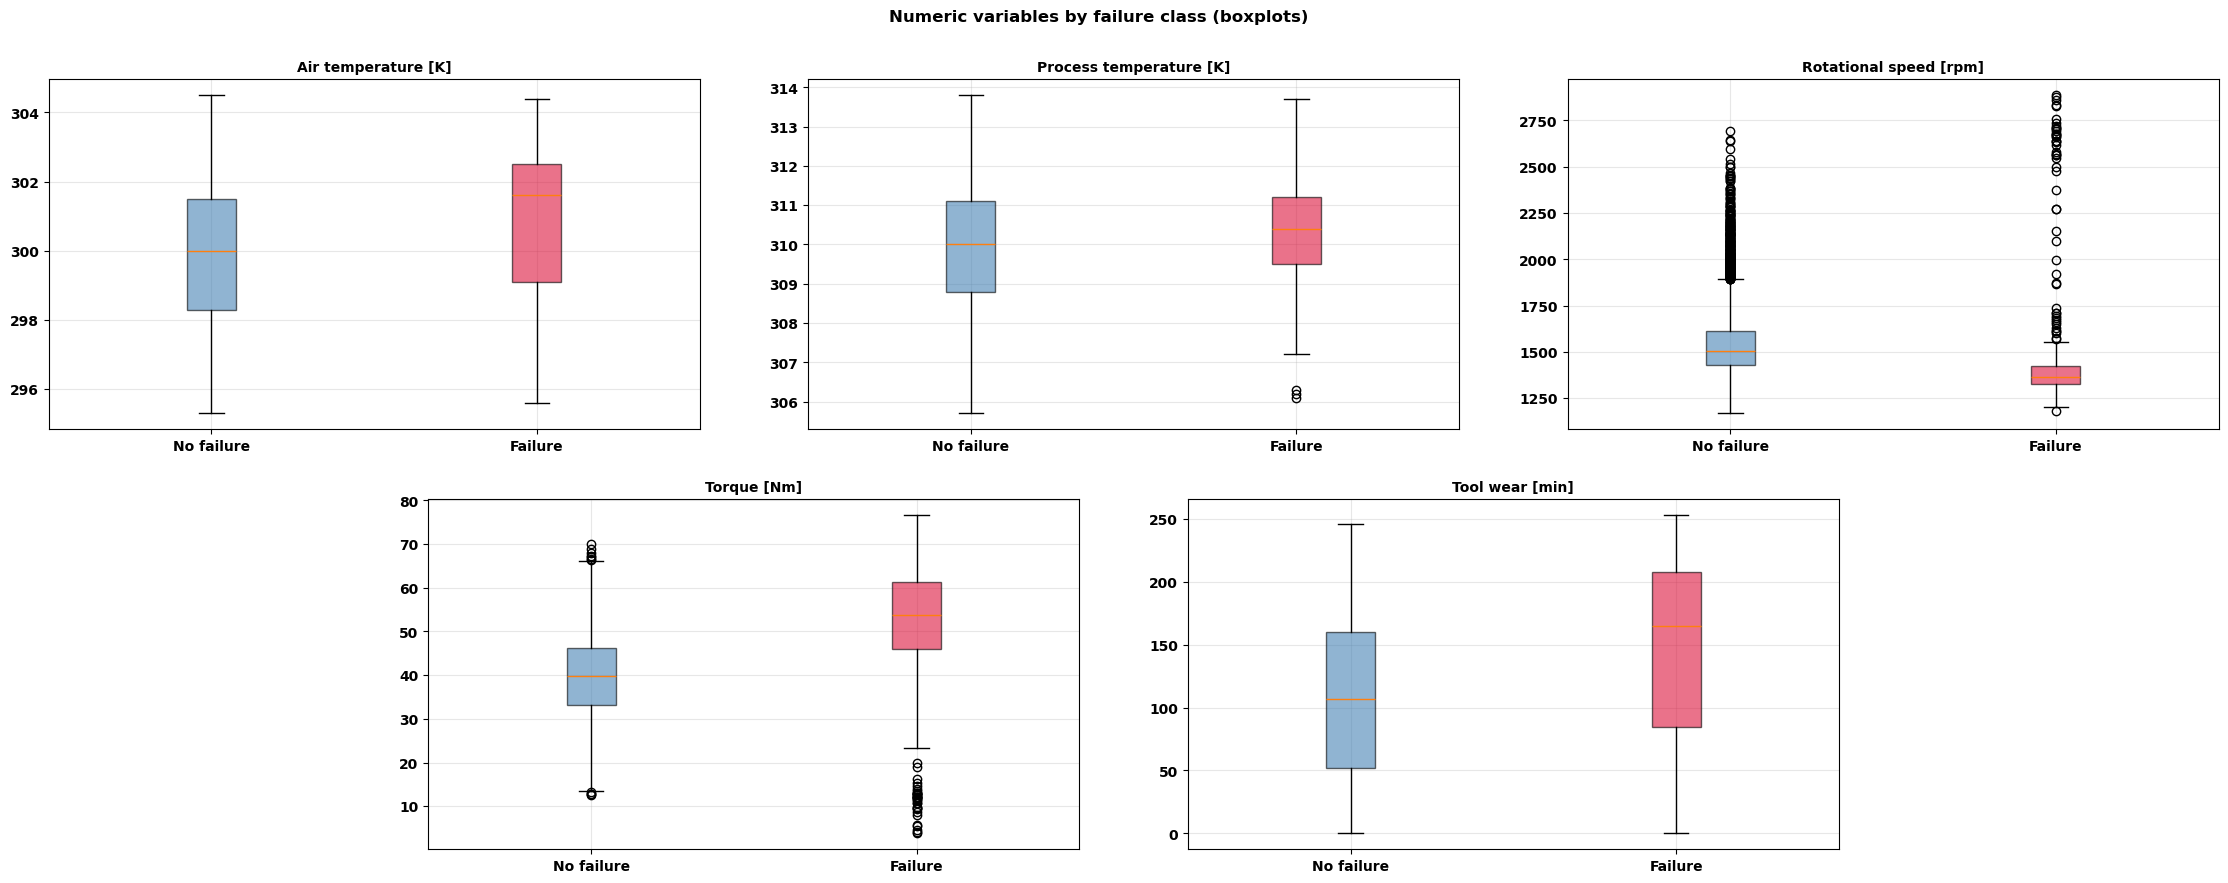

In [10]:
# Boxplots by failure class
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(28, 10))
gs  = gridspec.GridSpec(2, 6, figure=fig, hspace=0.2, wspace=0.40)
ax_top = [fig.add_subplot(gs[0, i*2:(i+1)*2]) for i in range(3)]
ax_bot = [fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]
axes = ax_top + ax_bot

for ax, col in zip(axes, NUM_COLS):
    data_pairs = [df.loc[df[TARGET] == 0, col], df.loc[df[TARGET] == 1, col]]
    bp = ax.boxplot(data_pairs, tick_labels=["No failure", "Failure"], patch_artist=True)
    for patch, color in zip(bp["boxes"], ["steelblue", "crimson"]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(col, fontsize=10)

plt.suptitle("Numeric variables by failure class (boxplots)", y=0.95)
plt.show()

## 5. Failure-rate pattern analysis     

For each main variable, the data is divided into quantile bins and the failure rate per bin is computed     
Bin-level support counts are reported alongside the rate so small bins are not over-interpreted     

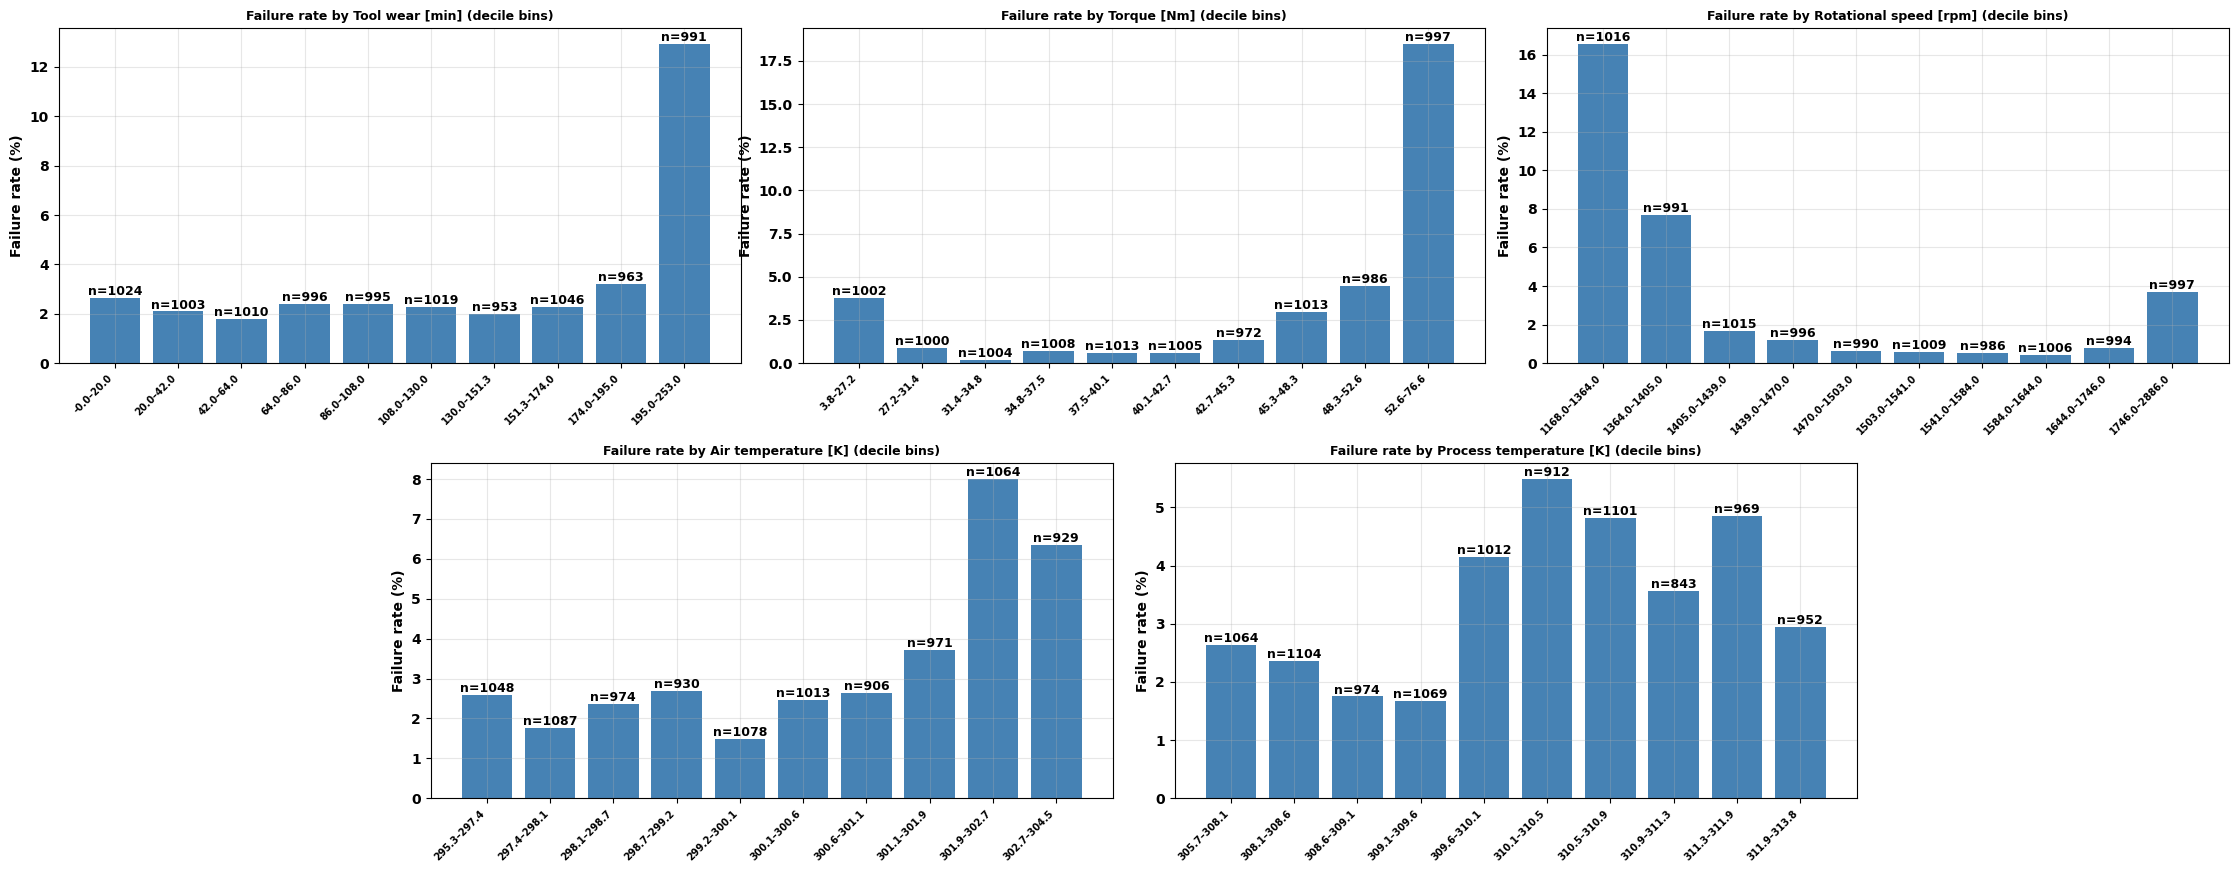

In [11]:
def failure_rate_by_quantile(df, col, q=10):
    bins = pd.qcut(df[col], q=q, duplicates="drop")
    g = df.groupby(bins, observed=True)[TARGET].agg(["sum", "count"])
    g["failure_rate_%"] = (g["sum"] / g["count"] * 100).round(2)
    g.index.name = f"{col} (quantile bin)"
    return g

binned_targets = ["Tool wear [min]", "Torque [Nm]", "Rotational speed [rpm]",
                  "Air temperature [K]", "Process temperature [K]"]

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(28, 10))
gs  = gridspec.GridSpec(2, 6, figure=fig, hspace=0.3, wspace=0.2)
ax_top = [fig.add_subplot(gs[0, i*2:(i+1)*2]) for i in range(3)]
ax_bot = [fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])]
axes = ax_top + ax_bot

all_binned = {}
for ax, col in zip(axes, binned_targets):
    g = failure_rate_by_quantile(df, col, q=10)
    all_binned[col] = g
    x = np.arange(len(g))
    ax.bar(x, g["failure_rate_%"], color="steelblue")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{i.left:.1f}–{i.right:.1f}" for i in g.index],
                       rotation=45, ha="right", fontsize=7)
    for i, n in enumerate(g["count"].values):
        ax.text(i, g["failure_rate_%"].iloc[i], f"n={n}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Failure rate by {col} (decile bins)", fontsize=9)
    ax.set_ylabel("Failure rate (%)")

plt.show()

## 6. Relationship plots        

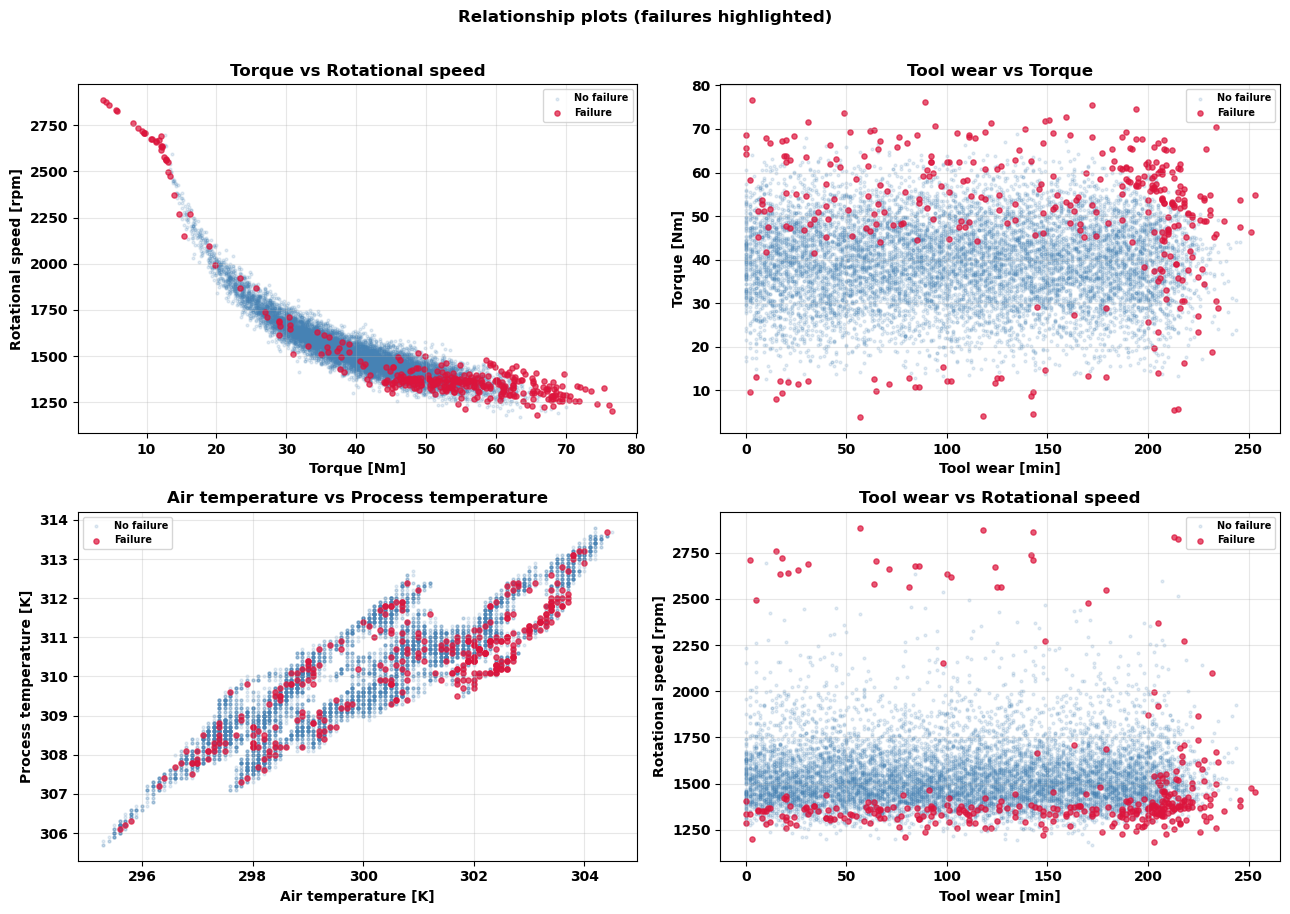

In [12]:
# Helper to plot a 2D scatter coloured by failure status
def scatter_by_failure(df, x, y, ax):
    nf = df[df[TARGET] == 0]
    f  = df[df[TARGET] == 1]
    ax.scatter(nf[x], nf[y], s=4, alpha=0.15, color="steelblue", label="No failure")
    ax.scatter(f[x],  f[y],  s=14, alpha=0.7, color="crimson", label="Failure")
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.legend(fontsize=7)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
scatter_by_failure(df, "Torque [Nm]", "Rotational speed [rpm]", axes[0, 0])
axes[0, 0].set_title("Torque vs Rotational speed")
scatter_by_failure(df, "Tool wear [min]", "Torque [Nm]", axes[0, 1])
axes[0, 1].set_title("Tool wear vs Torque")
scatter_by_failure(df, "Air temperature [K]", "Process temperature [K]", axes[1, 0])
axes[1, 0].set_title("Air temperature vs Process temperature")
scatter_by_failure(df, "Tool wear [min]", "Rotational speed [rpm]", axes[1, 1])
axes[1, 1].set_title("Tool wear vs Rotational speed")
plt.suptitle("Relationship plots (failures highlighted)", y=1.01)
plt.tight_layout()
plt.show()

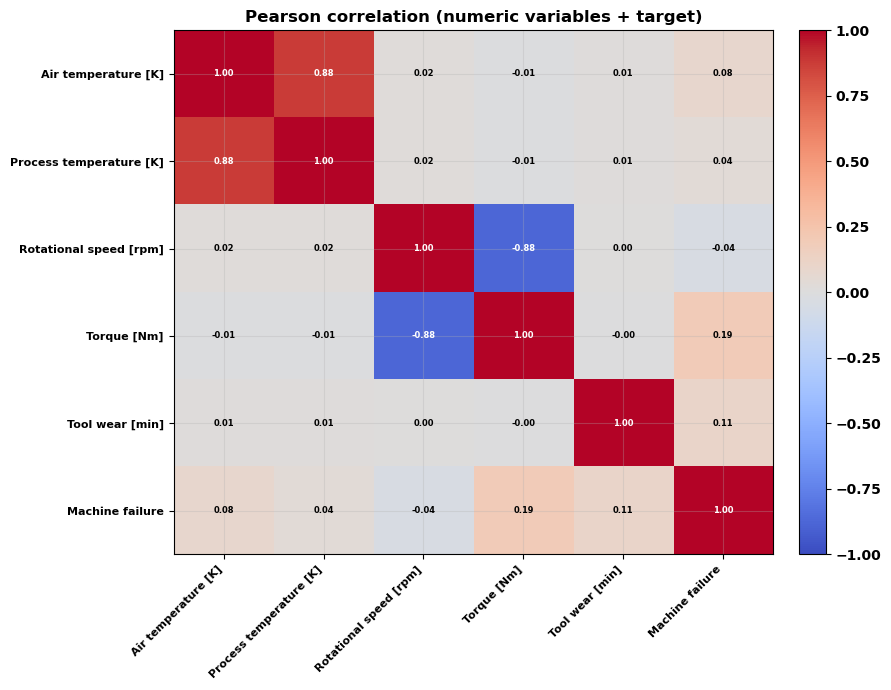

In [13]:
# Correlation heatmap with target
corr_cols = NUM_COLS + [TARGET]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(corr_cols)))
ax.set_yticklabels(corr_cols, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(v) > 0.6 else "black")
ax.set_title("Pearson correlation (numeric variables + target)")
plt.tight_layout()
plt.show()

## 7. Subtype-specific interpretation       

For each failure subtype, summary statistics of the main variables are computed and compared to the no-failure group        

In [14]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    sx, sy = x.std(), y.std()
    pooled = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled if pooled > 0 else np.nan

subtype_rows = []
for sub in SUBTYPE_COLS:
    n = int(df[sub].sum())
    if n == 0:
        continue
    sub_data = df[df[sub] == 1]
    no_data  = df[df[TARGET] == 0]
    for col in NUM_COLS:
        d = cohens_d(sub_data[col], no_data[col])
        subtype_rows.append({
            "Subtype": sub, "n": n,
            "variable": col,
            "subtype_mean": sub_data[col].mean(),
            "no_failure_mean": no_data[col].mean(),
            "Cohen's d (subtype − no failure)": d,
        })

subtype_effects = pd.DataFrame(subtype_rows)
print("Subtype effect-size summary (sorted by |d|, top 15):")
print(subtype_effects.assign(abs_d=lambda x: x["Cohen's d (subtype − no failure)"].abs())
                   .sort_values("abs_d", ascending=False)
                   .drop(columns=["abs_d"])
                   .head(15)
                   .round(3)
                   .to_string(index=False))

Subtype effect-size summary (sorted by |d|, top 15):
Subtype   n                variable  subtype_mean  no_failure_mean  Cohen's d (subtype − no failure)
    OSF  98             Torque [Nm]        58.370           39.630                             1.985
    TWF  46         Tool wear [min]       216.370          106.694                             1.746
    OSF  98         Tool wear [min]       207.694          106.694                             1.612
    HDF 115             Torque [Nm]        53.167           39.630                             1.434
    HDF 115     Air temperature [K]       302.561          299.974                             1.306
    PWF  95  Rotational speed [rpm]      1763.968         1540.260                             1.261
    HDF 115  Rotational speed [rpm]      1337.261         1540.260                            -1.220
    OSF  98  Rotational speed [rpm]      1350.327         1540.260                            -1.140
    PWF  95             Torque [Nm]   

In [15]:
# Top-associated variable per subtype
top_var_per_sub = (subtype_effects.assign(abs_d=lambda x: x["Cohen's d (subtype − no failure)"].abs())
                              .sort_values(["Subtype", "abs_d"], ascending=[True, False])
                              .groupby("Subtype")
                              .head(1))
print("Top-associated variable per subtype:")
print(top_var_per_sub.round(3).to_string(index=False))

Top-associated variable per subtype:
Subtype   n                variable  subtype_mean  no_failure_mean  Cohen's d (subtype − no failure)  abs_d
    HDF 115             Torque [Nm]        53.167           39.630                             1.434  1.434
    OSF  98             Torque [Nm]        58.370           39.630                             1.985  1.985
    PWF  95  Rotational speed [rpm]      1763.968         1540.260                             1.261  1.261
    RNF  19 Process temperature [K]       310.763          309.996                             0.516  0.516
    TWF  46         Tool wear [min]       216.370          106.694                             1.746  1.746


## 8. Non-optimal operating condition patterns      

Drawing on the binned analysis (Section 5), the relationship plots (Section 6), and the subtype summaries (Section 7), a small set of *high-risk operating regions* can be characterised        

In [16]:
# Define candidate high-risk regions and report failure rate/support
def region_summary(df, mask, label):
    n = int(mask.sum())
    if n == 0:
        return {"region": label, "n": 0, "failures": 0, "failure_rate_%": np.nan}
    fails = int((df.loc[mask, TARGET] == 1).sum())
    return {"region": label, "n": n, "failures": fails,
            "failure_rate_%": round(100 * fails / n, 2)}

regions = [
    region_summary(df, df["Tool wear [min]"] > 200,
                   "Tool wear > 200 min"),
    region_summary(df, (df["Tool wear [min]"] > 200) & (df["Torque [Nm]"] > 50),
                   "Tool wear > 200 AND Torque > 50 Nm"),
    region_summary(df, df["Rotational speed [rpm]"] < 1380,
                   "Rotational speed < 1380 rpm"),
    region_summary(df, df["Torque [Nm]"] > 60,
                   "Torque > 60 Nm"),
    region_summary(df,
                   (df["Process temperature [K]"] - df["Air temperature [K]"]) < 8.6,
                   "Process temp - Air temp < 8.6 K"),
]
regions_df = pd.DataFrame(regions)
print(regions_df.to_string(index=False))

                            region    n  failures  failure_rate_%
               Tool wear > 200 min  762       118           15.49
Tool wear > 200 AND Torque > 50 Nm  107        62           57.94
       Rotational speed < 1380 rpm 1360       218           16.03
                    Torque > 60 Nm  236        99           41.95
   Process temp - Air temp < 8.6 K  720       126           17.50
